In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("C:/Users/dell/Desktop/OpenOffice Files/PP/global air pollution dataset.csv")

In [3]:
print(df.head())

              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2               Italy   Priolo Gargallo         66     Moderate             1   
3              Poland         Przasnysz         34         Good             1   
4              France          Punaauia         22         Good             0   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good               39               Good              2   
3            Good               34               Good              0   
4            Good               22               Good              0   

  NO2 AQI Category  PM2.5 AQI Value PM2.5 AQI Category  
0             Good     

In [4]:
print(df.columns)

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')


In [5]:
print(df.shape)

(23463, 12)


In [6]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB
None
Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQ

In [7]:
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
          AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  \
count  23463.000000  23463.000000     23463.000000   23463.000000   
mean      72.010868      1.368367        35.193709       3.063334   
std       56.055220      1.832064        28.098723       5.254108   
min        6.000000      0.000000         0.000000       0.000000   
25%       39.000000      1.000000        21.000000       0.000000   
50%       55.000000      1.000000        31.000000       1.000000   
75%       79.000000      1.000000        40.000000       4.000000   
max      500.000000    133.000000       235.000000      91.000000   

       PM2.5 AQI Value  
count     23463.000000  
mean         68.519755  
std          54.796443  
min           0.000000  
25%          35.000000  
50%          54.000000  
75%          79.000000  
max         500.000000  


In [8]:
country_aqi = (
    df.groupby("Country", as_index=False)["AQI Value"]
    .mean()
    .sort_values("AQI Value", ascending=False)
    .head(10)
)

print(country_aqi)

                  Country   AQI Value
126     Republic of Korea  421.000000
11                Bahrain  188.000000
98             Mauritania  179.000000
116              Pakistan  178.788274
163  United Arab Emirates  163.666667
7                   Aruba  163.000000
82                 Kuwait  162.000000
125                 Qatar  157.500000
69                  India  152.964228
135               Senegal  152.424242


In [9]:
fig = px.bar(
    country_aqi,
    x="AQI Value",
    y="Country",
    orientation="h",
    title="Top 10 Countries by Average AQI (Mrunmayee Uade)",
    labels={
        "AQI Value": "Average AQI",
        "Country": "Country"
    }
)

fig.update_layout(
    template="plotly_white",
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

In [10]:
fig = px.histogram(
    df,
    x="AQI Value",
    nbins=50,
    title="Distribution of Air Quality Index (AQI) Purva Vaidya",
    labels={
        "AQI Value": "Air Quality Index"
    }
)

fig.update_layout(
    xaxis_title="AQI Value",
    yaxis_title="Number of Locations",
    template="plotly_white"
)

fig.show()

In [11]:
Sfig = px.scatter(
    df,
    x="NO2 AQI Value",
    y="AQI Value",
    title="Relationship Between NO₂ and AQI (Purva Vaidya)",
    labels={
        "NO2 AQI Value": "NO₂ AQI",
        "AQI Value": "Overall AQI"
    },
    trendline="ols",
    opacity=0.6
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

In [12]:
pollutants = [
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

pollution_data = df[pollutants].melt(
    var_name="Pollutant",
    value_name="AQI"
)

fig = px.box(
    pollution_data,
    x="Pollutant",
    y="AQI",
    title="Distribution of Air Pollutants (Purva Vaidya)",
    labels={
        "Pollutant": "Pollutant",
        "AQI": "AQI Value"
    }
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

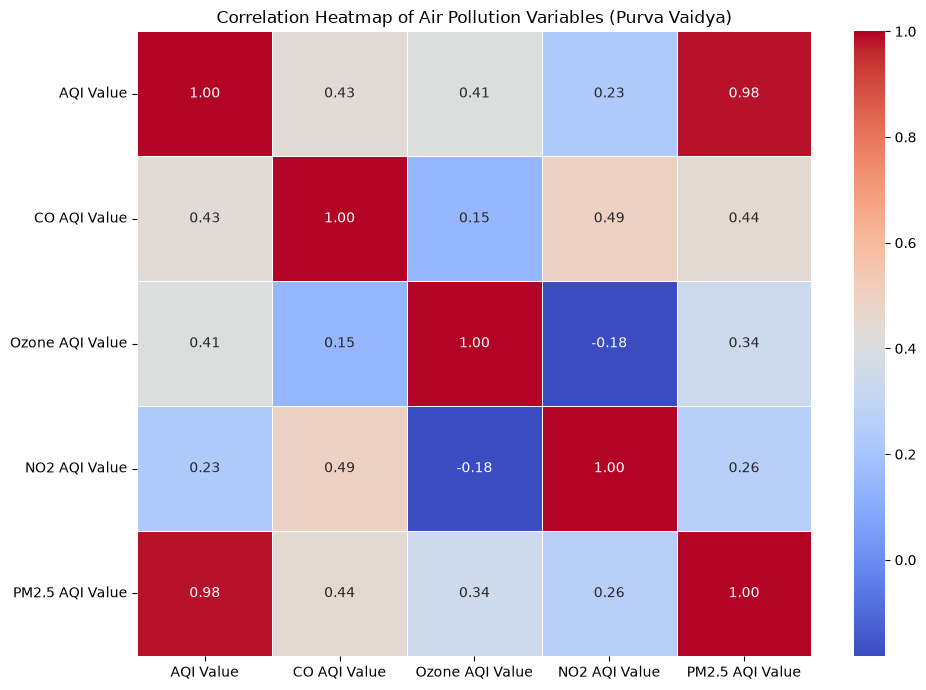

In [13]:
pollution_columns = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

correlation = df[pollution_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Air Pollution Variables (Purva Vaidya)")
plt.tight_layout()
plt.show()

In [14]:
aqi_correlation = (
    correlation["AQI Value"]
    .drop("AQI Value")
    .sort_values(ascending=False)
)

print("Correlation of pollutants with AQI:")
print(aqi_correlation)

Correlation of pollutants with AQI:
PM2.5 AQI Value    0.984327
CO AQI Value       0.430602
Ozone AQI Value    0.405310
NO2 AQI Value      0.231758
Name: AQI Value, dtype: float64


In [15]:
country_data = (
    df.groupby("Country", as_index=False)
    .agg(
        Average_AQI=("AQI Value", "mean"),
        Number_of_Cities=("City", "nunique")
    )
    .sort_values("Average_AQI", ascending=False)
)

fig = px.scatter(
    country_data,
    x="Number_of_Cities",
    y="Average_AQI",
    hover_name="Country",
    title="Average AQI vs Number of Cities by Country (Purva Vaidya)",
    labels={
        "Number_of_Cities": "Number of Cities",
        "Average_AQI": "Average AQI"
    }
)

fig.update_layout(
    template="plotly_white"
)

fig.show()